In [1]:
# Week 4 Homework - Pull historical price data from CoinGecko API

In [2]:
# Step 1: Import libraries
# ----------------------------------------
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 2. Define Query Parameters
params = {
    "vs_currency": "usd",
    "days": "30",  # Pull last 30 days of data
}

In [5]:
# 3. Load API key, build target request
import os
import requests
from dotenv import load_dotenv

# Load variables from the hidden .env file into the system environment
load_dotenv()  #

# Get the API key securely from the environment
api_key = os.getenv("COINGECKO_API_KEY")  #

# Build target request
coin_id = "bitcoin"
url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"

params = {
    "vs_currency": "usd",
    "days": "30",
}

# Pass the secret variable into your request headers
headers = {
    "accept": "application/json",
    "x-cg-demo-api-key": api_key,  # Uses the hidden key
}

response = requests.get(url, params=params, headers=headers)
print("Status Code:", response.status_code)

Status Code: 200


In [7]:
# Request API data, transfer to json
try:
    # 4. Make the HTTP GET request
    response = requests.get(url, params=params, headers=headers)
    response.raise_for_status()  # Check for HTTP errors (4xx / 5xx)

    # 5. Parse JSON data
    data = response.json()

    # The endpoint returns lists of [timestamp_ms, value] pairs:
    # - prices
    # - market_caps
    # - total_volumes
    prices = data.get("prices", [])

    print(f"Successfully retrieved {len(prices)} historical price points for {coin_id}.\n")

    # Display the first 5 data entries
    print("Sample Data (Timestamp in ms, Price in USD):")
    for entry in prices[:30]:
        timestamp = entry[0]
        price = entry[1]
        print(f"Timestamp: {timestamp} | Price: ${price:,.2f}")

except requests.exceptions.RequestException as e:
    print(f"An error occurred while calling CoinGecko API: {e}")

Successfully retrieved 721 historical price points for bitcoin.

Sample Data (Timestamp in ms, Price in USD):
Timestamp: 1785348000000 | Price: $64,250.22
Timestamp: 1785351600000 | Price: $64,430.91
Timestamp: 1785355200000 | Price: $63,528.92
Timestamp: 1785358800000 | Price: $63,450.03
Timestamp: 1785362400000 | Price: $63,782.51
Timestamp: 1785366000000 | Price: $63,874.13
Timestamp: 1785369600000 | Price: $63,916.60
Timestamp: 1785373200000 | Price: $63,620.89
Timestamp: 1785376800000 | Price: $64,196.00
Timestamp: 1785380400000 | Price: $64,112.04
Timestamp: 1785384000000 | Price: $64,091.60
Timestamp: 1785387600000 | Price: $63,955.59
Timestamp: 1785391200000 | Price: $63,954.10
Timestamp: 1785394800000 | Price: $63,921.02
Timestamp: 1785398400000 | Price: $63,941.79
Timestamp: 1785402000000 | Price: $64,231.80
Timestamp: 1785405600000 | Price: $64,499.35
Timestamp: 1785409200000 | Price: $64,505.23
Timestamp: 1785412800000 | Price: $64,731.19
Timestamp: 1785416400000 | Price: $

In [8]:
# Add volume to data
prices = data.get("prices", [])
volumes = data.get("total_volumes", [])

# Merge prices and volumes into a single list
daily_data = []
for p, v in zip(prices, volumes):
    timestamp = p[0]  # timestamp in milliseconds
    price_val = p[1]
    volume_val = v[1]
    
    daily_data.append({
        "timestamp": timestamp,
        "price": price_val,
        "total_volume": volume_val
    })

# Accessing the combined data
print(daily_data[0]) 
# -> {'timestamp': 1700000000000, 'price': 45000.5, 'total_volume': 15000000000.0}

{'timestamp': 1785348000000, 'price': 64250.21690005848, 'total_volume': 23969416922.157234}


In [9]:
# Create table or dataframe
import pandas as pd

# 1. Convert the list of dictionaries directly into a DataFrame
df = pd.DataFrame(daily_data)

# 2. Convert Unix millisecond timestamps into human-readable datetimes
df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")

# 3. Clean up and reorder columns
df = df[["datetime", "price", "total_volume"]]

# Display the first 5 formatted rows
print(df.head())

             datetime         price  total_volume
0 2026-07-29 18:00:00  64250.216900  2.396942e+10
1 2026-07-29 19:00:00  64430.914861  2.591271e+10
2 2026-07-29 20:00:00  63528.923490  2.680944e+10
3 2026-07-29 21:00:00  63450.027893  2.760124e+10
4 2026-07-29 22:00:00  63782.512929  2.839072e+10


In [10]:
# Add column volume_to_price_ratio
df["vol_price_ratio"] = df["total_volume"] / df["price"]

In [11]:
print(df.head())

             datetime         price  total_volume  vol_price_ratio
0 2026-07-29 18:00:00  64250.216900  2.396942e+10    373063.595403
1 2026-07-29 19:00:00  64430.914861  2.591271e+10    402178.276991
2 2026-07-29 20:00:00  63528.923490  2.680944e+10    422003.692054
3 2026-07-29 21:00:00  63450.027893  2.760124e+10    435007.532984
4 2026-07-29 22:00:00  63782.512929  2.839072e+10    445117.603652


In [12]:
# Grab just one data point per day, use closing price and aggregate for average volume for that day
import pandas as pd

# 1. Create DataFrame from your combined list
df = pd.DataFrame(daily_data)

# 2. Convert timestamp to datetime
df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")

# 3. Extract just the date component (YYYY-MM-DD)
df["date"] = df["datetime"].dt.date

# 4. Group by date taking the last price (daily close) and the average or max volume
daily_df = df.groupby("date").agg({
    "price": "last",          # Daily closing price
    "total_volume": "mean"    # Average volume for that day (or use "max")
}).reset_index()

print(daily_df.head())

         date         price  total_volume
0  2026-07-29  63874.127563  2.691547e+10
1  2026-07-30  64803.410852  2.914688e+10
2  2026-07-31  62888.411834  2.783597e+10
3  2026-08-01  62780.240317  2.148948e+10
4  2026-08-02  63371.397926  1.517129e+10


In [13]:
# Add simple moving average
# 2. Add a 7-day Simple Moving Average (SMA)
daily_df["sma_7"] = daily_df["price"].rolling(window=7).mean()

# Display the updated DataFrame
print(daily_df.tail(10))

          date         price  total_volume         sma_7
21  2026-08-19  69221.139608  2.355511e+10  64325.023203
22  2026-08-20  72660.836660  5.618579e+10  65637.273280
23  2026-08-21  78447.001746  6.488939e+10  67868.298599
24  2026-08-22  76998.181802  5.532597e+10  69857.054789
25  2026-08-23  77588.632845  2.993685e+10  71964.376197
26  2026-08-24  78727.756284  3.858175e+10  74034.190369
27  2026-08-25  78879.417778  5.092071e+10  76074.709532
28  2026-08-26  78708.997983  3.297551e+10  77430.117871
29  2026-08-27  80297.004179  3.045600e+10  78520.998945
30  2026-08-28  77810.000688  3.525710e+10  78429.998794


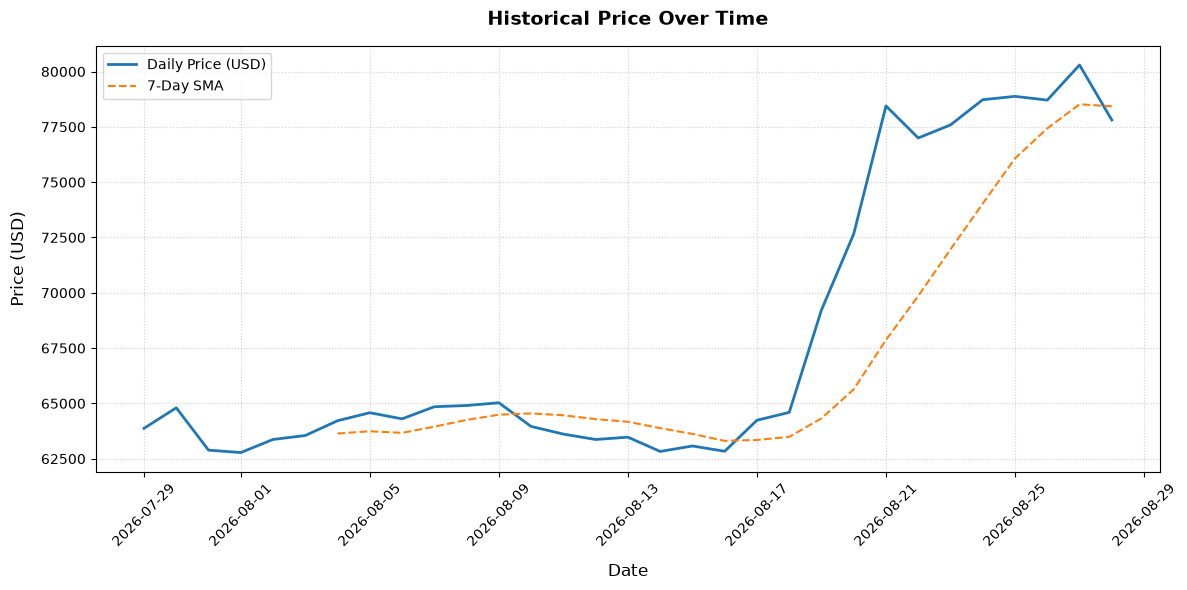

In [14]:
import matplotlib.pyplot as plt

# Create figure and axis
plt.figure(figsize=(12, 6))

# Plot historical price
plt.plot(
    daily_df["date"],
    daily_df["price"],
    label="Daily Price (USD)",
    color="#1f77b4",
    linewidth=2,
)

# Optional: Add the 7-day Moving Average if calculated in your DataFrame
if "sma_7" in daily_df.columns:
    plt.plot(
        daily_df["date"],
        daily_df["sma_7"],
        label="7-Day SMA",
        color="#ff7f0e",
        linewidth=1.5,
        linestyle="--",
    )

# Formatting and Labels
plt.title("Historical Price Over Time", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=12, labelpad=10)
plt.ylabel("Price (USD)", fontsize=12, labelpad=10)

# Grid, Legend, and Layout cleanup
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left", frameon=True)
plt.xticks(rotation=45)
plt.tight_layout()

# Display plot
plt.show()

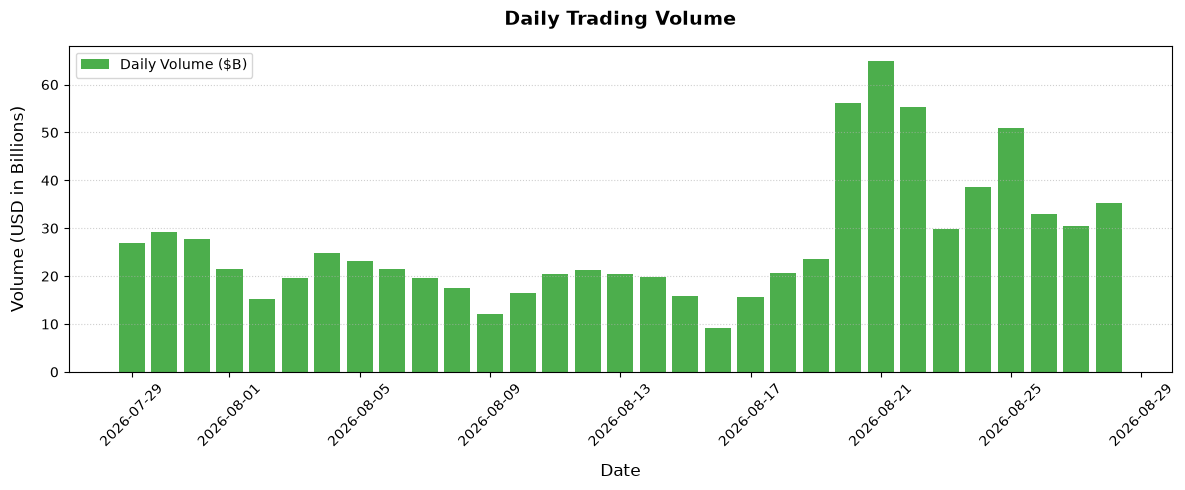

In [16]:
# Plot daily volume

# Create figure
plt.figure(figsize=(12, 5))

# Plot daily volume as a bar chart (dividing by 1e9 scales values into Billions)
plt.bar(
    daily_df["date"],
    daily_df["total_volume"] / 1e9,
    color="#2ca02c",
    alpha=0.85,
    width=0.8,
    label="Daily Volume ($B)",
)

# Formatting and Labels
plt.title("Daily Trading Volume", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=12, labelpad=10)
plt.ylabel("Volume (USD in Billions)", fontsize=12, labelpad=10)

# Layout adjustments
plt.grid(True, axis="y", linestyle=":", alpha=0.6)
plt.xticks(rotation=45)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()

# Display plot
plt.show()

In [17]:
# Calculate daily percentage change in price

# Calculate daily percentage change
daily_df["price_pct_change"] = daily_df["price"].pct_change() * 100

# Display the updated DataFrame
print(daily_df.head())

         date         price  total_volume  sma_7  price_pct_change
0  2026-07-29  63874.127563  2.691547e+10    NaN               NaN
1  2026-07-30  64803.410852  2.914688e+10    NaN          1.454867
2  2026-07-31  62888.411834  2.783597e+10    NaN         -2.955090
3  2026-08-01  62780.240317  2.148948e+10    NaN         -0.172005
4  2026-08-02  63371.397926  1.517129e+10    NaN          0.941630


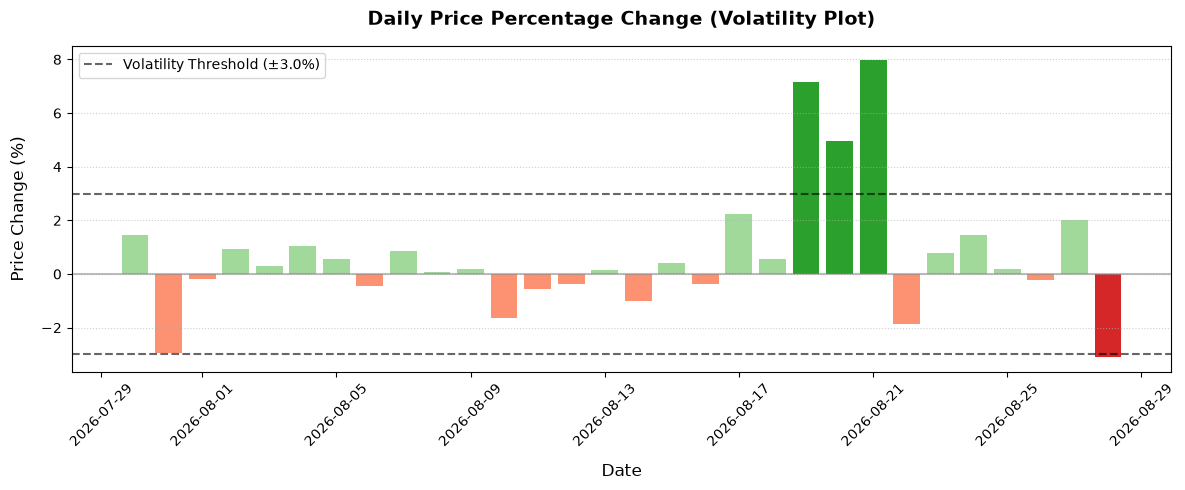

In [18]:
# Chart daily percentage of price changes use heat map to show volatile days
# Color Coding: Days exceeding your defined volatility threshold (e.g., $\ge +3\%$ or $\le -3\%$) are rendered in bold green or red, 
# while normal days stay muted.   
# Dashed Threshold Lines: Dashed horizontal lines highlight high-volatility events instantly.
# Zero Baseline: A neutral reference line splits gains from losses.


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Ensure dates are formatted and data is sorted
daily_df["date"] = pd.to_datetime(daily_df["date"])
daily_df = daily_df.sort_values("date")

# 2. Define a volatility threshold (e.g., +/- 3% move)
threshold = 3.0

# 3. Assign color intensity based on gain/loss and threshold breaches
colors = []
for change in daily_df["price_pct_change"]:
    if change >= threshold:
        colors.append("#2ca02c")  # High Volatility Green
    elif change <= -threshold:
        colors.append("#d62728")  # High Volatility Red
    elif change > 0:
        colors.append("#a1d99b")  # Normal Green
    else:
        colors.append("#fc9272")  # Normal Red

# 4. Create Figure
plt.figure(figsize=(12, 5))
plt.bar(
    daily_df["date"],
    daily_df["price_pct_change"],
    color=colors,
    width=0.8,
)

# 5. Add horizontal threshold reference lines
plt.axhline(
    threshold,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"Volatility Threshold (±{threshold}%)",
)
plt.axhline(-threshold, color="black", linestyle="--", alpha=0.6)
plt.axhline(0, color="gray", linestyle="-", alpha=0.5)

# Formatting
plt.title(
    "Daily Price Percentage Change (Volatility Plot)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Date", fontsize=12, labelpad=10)
plt.ylabel("Price Change (%)", fontsize=12, labelpad=10)
plt.grid(True, axis="y", linestyle=":", alpha=0.6)
plt.xticks(rotation=45)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()

plt.show()

In [19]:
# Calculate volatility
# 1. Calculate absolute percentage change to measure magnitude
daily_df["abs_pct_change"] = daily_df["price_pct_change"].abs()

# 2. Find the index of the maximum price move
max_volatile_idx = daily_df["abs_pct_change"].idxmax()

# 3. Extract details for that specific day
volatile_day = daily_df.loc[max_volatile_idx]

# 4. Calculate average daily volume across the dataset for comparison
avg_volume = daily_df["total_volume"].mean()
volume_ratio = volatile_day["total_volume"] / avg_volume

print("=== MOST VOLATILE DAY ANALYSIS ===")
print(f"Date:                   {volatile_day['date']}")
print(f"Price Change:           {volatile_day['price_pct_change']:.2f}%")
print(
    f"Trading Volume:         ${volatile_day['total_volume'] / 1e9:.2f} Billion"
)
print(f"Volume vs. 30-Day Avg:  {volume_ratio:.2f}x higher than normal\n")

=== MOST VOLATILE DAY ANALYSIS ===
Date:                   2026-08-21 00:00:00
Price Change:           7.96%
Trading Volume:         $64.89 Billion
Volume vs. 30-Day Avg:  2.40x higher than normal

